# Predicting Insurance Claim Amounts

## Objective

The objective of this project is to estimate the medical insurance claim amount based on personal and health-related data.

This project uses a regression approach where the target variable is `annual_medical_cost`, which represents the estimated insurance claim amount or medical charges.

## Main Tasks

- Understand the dataset
- Clean and prepare the data
- Visualize the impact of age, BMI, and smoking status on insurance charges
- Train a Linear Regression model
- Evaluate the model using MAE, RMSE, and R² Score
- Summarize key insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [4]:
data_path = Path("../data/medical_insurance.csv")

df = pd.read_csv(data_path)

df.columns = df.columns.str.strip().str.lower()

df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (100000, 54)

Columns:
['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

alcohol_freq    30083
dtype: int64

In [9]:
target = "annual_medical_cost"

df["charges"] = df[target]

print("Target Column:", target)
df[[target, "charges"]].head()

Target Column: annual_medical_cost


,annual_medical_cost,charges
0,6938.06,6938.06
1,1632.61,1632.61
2,7661.01,7661.01
3,5130.27,5130.27
4,1700.73,1700.73


In [10]:
numeric_features = [
    "age",
    "income",
    "bmi",
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "medication_count",
    "deductible",
    "copay",
    "risk_score",
    "chronic_count",
    "hypertension",
    "diabetes",
    "had_major_procedure"
]

categorical_features = [
    "sex",
    "region",
    "urban_rural",
    "education",
    "smoker",
    "plan_type",
    "network_tier"
]

features = numeric_features + categorical_features

features = [col for col in features if col in df.columns]
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

df_model = df[features + [target]].copy()

df_model.head()

,age,income,bmi,visits_last_year,hospitalizations_last_3yrs,medication_count,deductible,copay,risk_score,chronic_count,...,diabetes,had_major_procedure,sex,region,urban_rural,education,smoker,plan_type,network_tier,annual_medical_cost
0,52,22700.0,27.4,2,0,4,1000,20,0.5714,1,...,0,0,Female,North,Suburban,Doctorate,Never,PPO,Bronze,6938.06
1,79,12800.0,26.6,2,0,3,1000,10,1.0000,2,...,0,0,Female,North,Urban,No HS,Never,POS,Gold,1632.61
2,68,40700.0,31.5,1,0,4,500,20,1.0000,3,...,0,0,Male,North,Rural,HS,Never,HMO,Platinum,7661.01
3,15,15600.0,31.6,0,0,1,500,20,0.2857,1,...,1,0,Male,North,Suburban,Some College,Never,HMO,Silver,5130.27
4,53,89600.0,30.5,3,0,2,500,10,0.8681,2,...,0,0,Male,Central,Suburban,Doctorate,Never,POS,Platinum,1700.73


In [11]:
for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in categorical_features:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

df_model = df_model.dropna(subset=[target])

df_model.isnull().sum().sum()

np.int64(0)

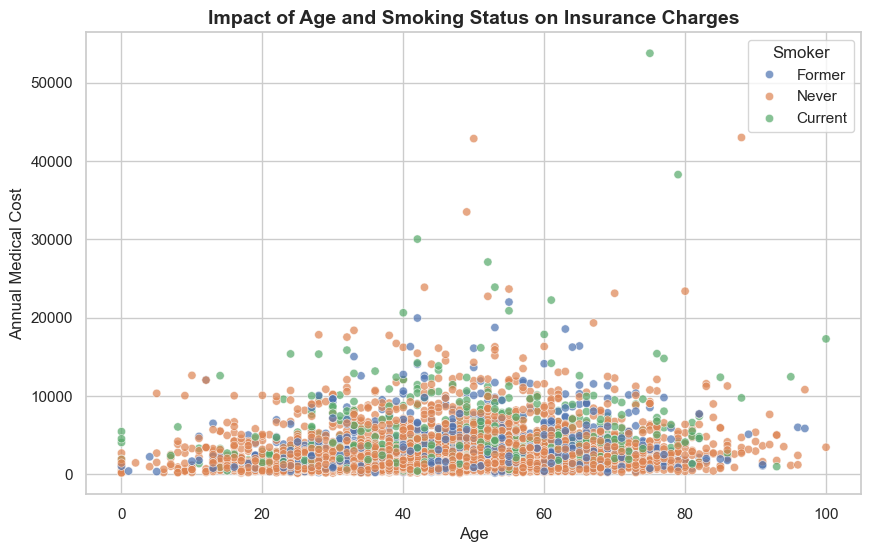

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model.sample(5000, random_state=42),
    x="age",
    y=target,
    hue="smoker",
    alpha=0.7
)
plt.title("Impact of Age and Smoking Status on Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")
plt.legend(title="Smoker")
plt.show()

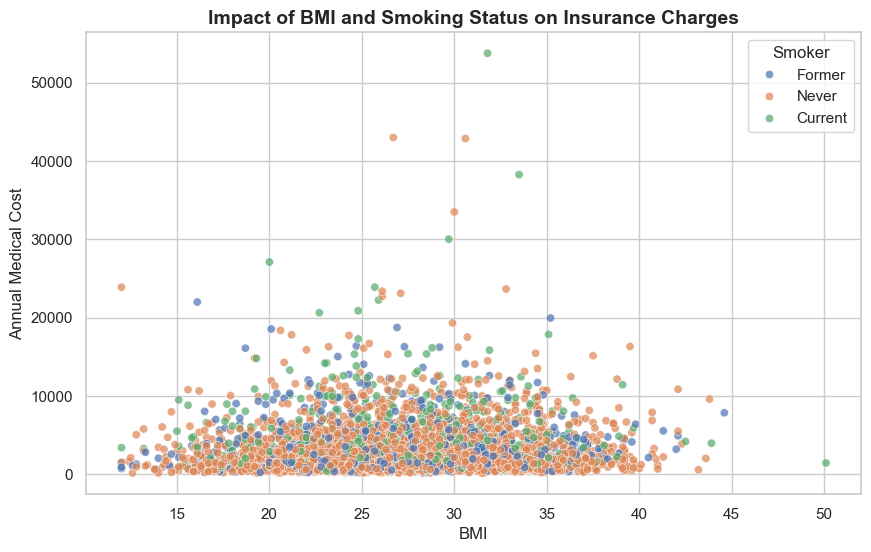

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model.sample(5000, random_state=42),
    x="bmi",
    y=target,
    hue="smoker",
    alpha=0.7
)
plt.title("Impact of BMI and Smoking Status on Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Annual Medical Cost")
plt.legend(title="Smoker")
plt.show()

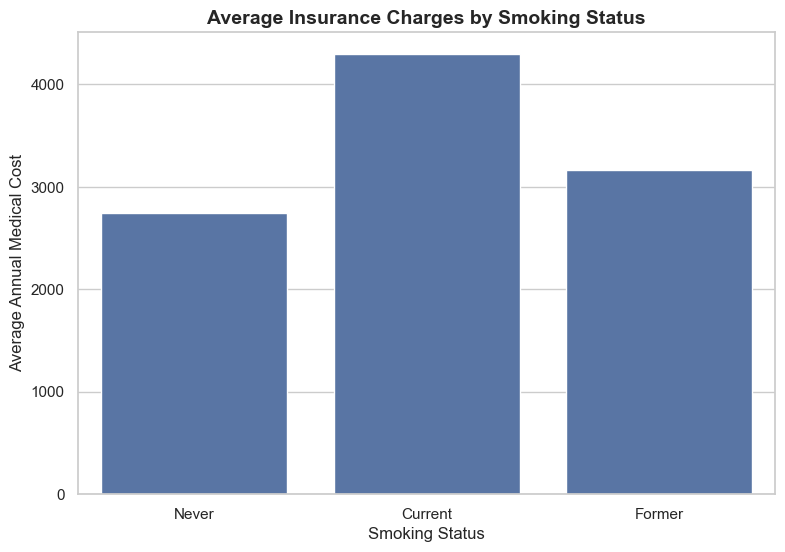

In [15]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_model,
    x="smoker",
    y=target,
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Insurance Charges by Smoking Status", fontsize=14, fontweight="bold")
plt.xlabel("Smoking Status")
plt.ylabel("Average Annual Medical Cost")
plt.show()

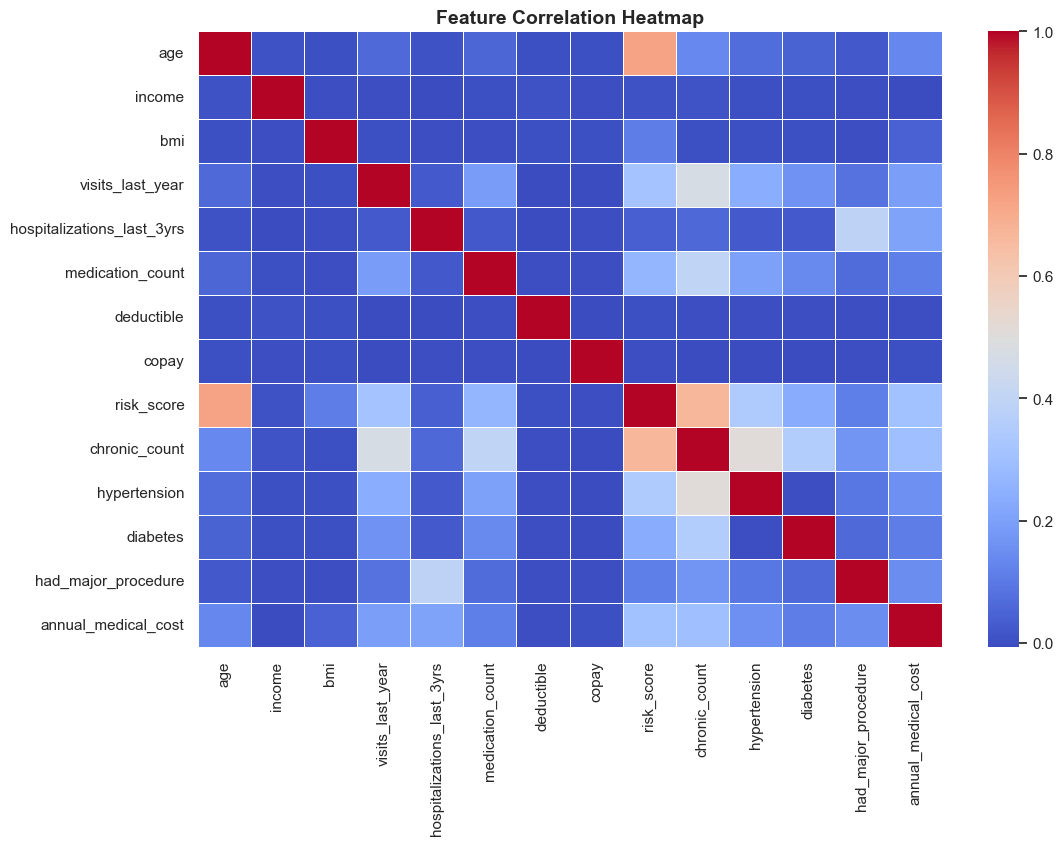

In [16]:
plt.figure(figsize=(12, 8))

corr = df_model[numeric_features + [target]].corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

In [17]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (80000, 20)
Testing Data: (20000, 20)


In [18]:
def create_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", create_one_hot_encoder(), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [19]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Evaluation Results
------------------------
MAE: 1777.91
RMSE: 2856.36
R² Score: 0.1709


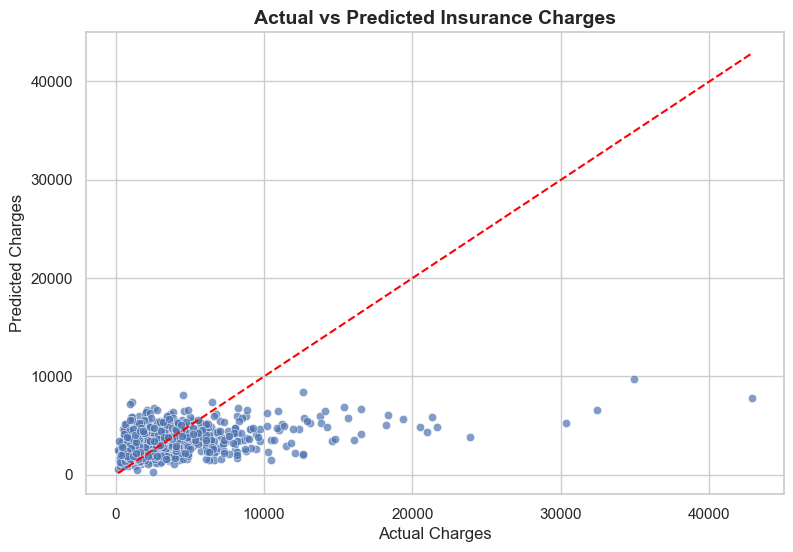

In [20]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

sample_results = results.sample(1000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_results,
    x="Actual",
    y="Predicted",
    alpha=0.7
)

plt.plot(
    [sample_results["Actual"].min(), sample_results["Actual"].max()],
    [sample_results["Actual"].min(), sample_results["Actual"].max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

# Conclusion

In this project, a Linear Regression model was trained to predict annual medical insurance claim amounts.

## Key Insights

- Age has a noticeable impact on medical insurance charges.
- BMI also affects charges, especially when combined with other health factors.
- Smoking status is one of the strongest visible factors influencing higher insurance costs.
- The model was evaluated using MAE, RMSE, and R² Score because this is a regression problem.

## Final Note

This project can be further improved by using advanced regression models such as Random Forest Regressor, Gradient Boosting Regressor, or XGBoost.

In [21]:
# ==============================
# SAVE ALL FIGURES (FINAL CELL)
# ==============================

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create directory
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", FIG_DIR.resolve())


# ------------------------------
# 1. Age vs Charges
# ------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model.sample(5000, random_state=42),
    x="age",
    y=target,
    hue="smoker",
    alpha=0.7
)
plt.title("Impact of Age and Smoking Status on Insurance Charges")
plt.tight_layout()
plt.savefig(FIG_DIR / "age_vs_charges.png", dpi=300)
plt.close()


# ------------------------------
# 2. BMI vs Charges
# ------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model.sample(5000, random_state=42),
    x="bmi",
    y=target,
    hue="smoker",
    alpha=0.7
)
plt.title("Impact of BMI and Smoking Status on Insurance Charges")
plt.tight_layout()
plt.savefig(FIG_DIR / "bmi_vs_charges.png", dpi=300)
plt.close()


# ------------------------------
# 3. Smoking Impact
# ------------------------------
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_model,
    x="smoker",
    y=target,
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Insurance Charges by Smoking Status")
plt.tight_layout()
plt.savefig(FIG_DIR / "smoker_vs_charges.png", dpi=300)
plt.close()


# ------------------------------
# 4. Correlation Heatmap
# ------------------------------
plt.figure(figsize=(12, 8))
corr = df_model[numeric_features + [target]].corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300)
plt.close()


# ------------------------------
# 5. Actual vs Predicted
# ------------------------------
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

sample_results = results.sample(1000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_results,
    x="Actual",
    y="Predicted",
    alpha=0.7
)

plt.plot(
    [sample_results["Actual"].min(), sample_results["Actual"].max()],
    [sample_results["Actual"].min(), sample_results["Actual"].max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted.png", dpi=300)
plt.close()


print("\n✅ All figures saved successfully in reports/figures/")

Saving figures to: D:\Predicting-Insurance-Claim-Amounts\reports\figures

✅ All figures saved successfully in reports/figures/
